# 01 — Environment Testing & EDA

**PAC-MAN-AI project — notebook 1 of 6.**

This notebook covers the **Data / Environment Loading & Validation** and **EDA** sections required by the course:

| Section | Content |
|---|---|
| Environment loading & validation | Instantiate `PacmanEnv`, verify observation/action spaces, inspect a reset state |
| EDA — observation space | Distribution of observation values, feature ranges |
| EDA — action space | Action counts over a random rollout |
| EDA — reward distribution | Per-step and cumulative reward over multiple random episodes |
| EDA — maze layout | Visual inspection of the board and pellet placement |
| EDA — episode length | Distribution of episode lengths under a random policy |


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

from src.environment.pacman_env import PacmanEnv
from src.environment.game_logic import DEFAULT_MAZE, ROWS, COLS, PELLET_SCORE, POWER_PELLET_SCORE

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style='whitegrid', palette='muted')
print('Imports OK')


Imports OK


In [2]:
## 2. Environment Loading & Validation

env = PacmanEnv(render_mode='ansi', seed=RANDOM_SEED)
obs, info = env.reset()

print('=== Observation space ===')
print(f'  Type:   {env.observation_space}')
print(f'  Shape:  {obs.shape}')
print(f'  dtype:  {obs.dtype}')
print(f'  min:    {obs.min():.4f}   max: {obs.max():.4f}')
print()
print('=== Action space ===')
print(f'  Type:   {env.action_space}')
print(f'  n_actions: {env.action_space.n}')
print(f'  Action map: {{0: UP, 1: DOWN, 2: LEFT, 3: RIGHT}}')
print()
print('=== Reset info ===')
print(f'  {info}')


=== Observation space ===
  Type:   Box(0.0, 1.0, (891,), float32)
  Shape:  (891,)
  dtype:  float32
  min:    0.0000   max: 1.0000

=== Action space ===
  Type:   Discrete(4)
  n_actions: 4
  Action map: {0: UP, 1: DOWN, 2: LEFT, 3: RIGHT}

=== Reset info ===
  {'score': 0, 'lives': 3, 'step': 0, 'max_steps': None}


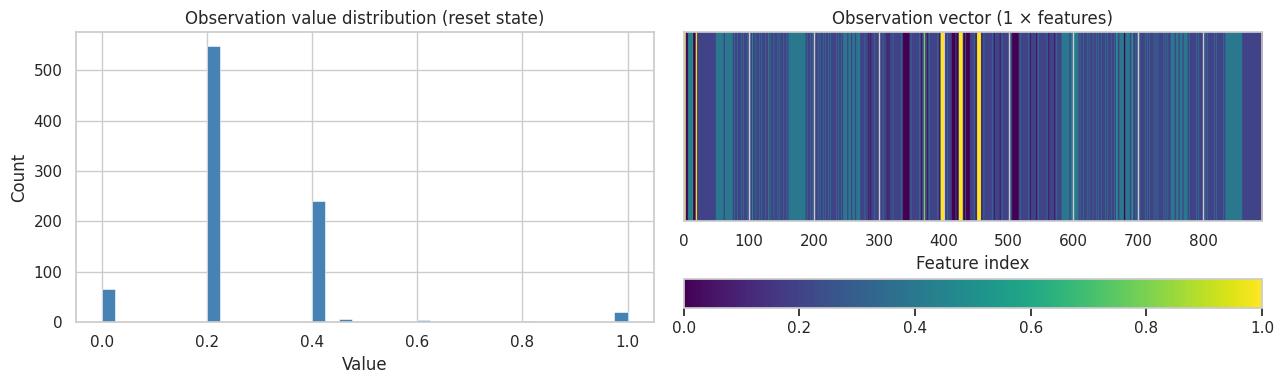

Observation vector length: 891  (6 agent/mode + 8 ghost pos + 4 frightened + 2 game state + 31×28 maze cells)


In [3]:
## 3. EDA — Observation Space

# Visualise the distribution of observation values at reset
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(obs, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title('Observation value distribution (reset state)')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Count')

# Show raw observation vector as a heatmap row
axes[1].imshow(obs.reshape(1, -1), aspect='auto', cmap='viridis')
axes[1].set_title('Observation vector (1 × features)')
axes[1].set_xlabel('Feature index')
axes[1].set_yticks([])
plt.colorbar(axes[1].images[0], ax=axes[1], orientation='horizontal', pad=0.2)

plt.tight_layout()
plt.savefig('../reports/eda_observation_space.png', dpi=120)
plt.show()
print(f'Observation vector length: {len(obs)}  (6 agent/mode + 8 ghost pos + 4 frightened + 2 game state + {ROWS}×{COLS} maze cells)')


/tmp/ipykernel_86888/2611061894.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', 4)


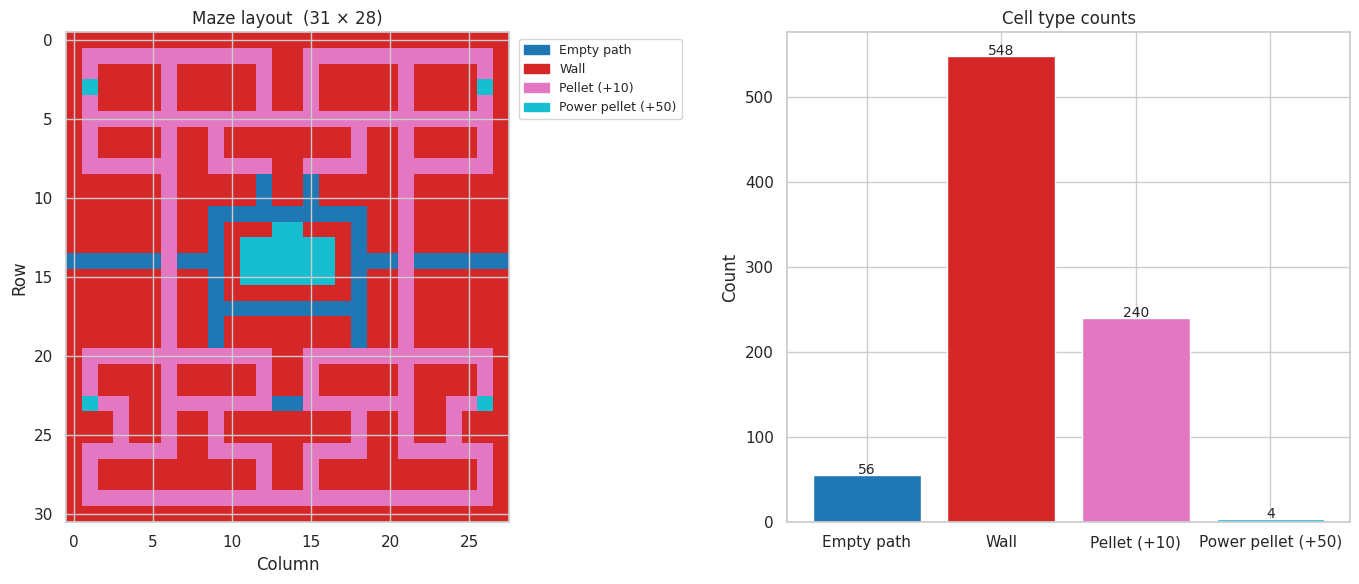

Total pellets: 244  |  Max pellet score (no ghosts): 2600


In [4]:
## 4. EDA — Maze Layout

maze = np.array(DEFAULT_MAZE)

# Colour map: 0=empty, 1=wall, 2=pellet, 3=power pellet
cmap = plt.cm.get_cmap('tab10', 4)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im = axes[0].imshow(maze, cmap=cmap, vmin=0, vmax=3, interpolation='nearest')
axes[0].set_title(f'Maze layout  ({ROWS} × {COLS})')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('Row')
legend_labels = {0: 'Empty path', 1: 'Wall', 2: 'Pellet (+10)', 3: 'Power pellet (+50)'}
patches = [mpatches.Patch(color=cmap(v), label=legend_labels[v]) for v in range(4)]
axes[0].legend(handles=patches, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

# Cell-type counts
cell_counts = {legend_labels[v]: int((maze == v).sum()) for v in range(4)}
axes[1].bar(cell_counts.keys(), cell_counts.values(), color=[cmap(v) for v in range(4)])
axes[1].set_title('Cell type counts')
axes[1].set_ylabel('Count')
for i, (k, v) in enumerate(cell_counts.items()):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/eda_maze_layout.png', dpi=120)
plt.show()

total_pellets = cell_counts['Pellet (+10)'] + cell_counts['Power pellet (+50)']
max_pellet_score = cell_counts['Pellet (+10)'] * PELLET_SCORE + cell_counts['Power pellet (+50)'] * POWER_PELLET_SCORE
print(f'Total pellets: {total_pellets}  |  Max pellet score (no ghosts): {max_pellet_score}')


Episodes: 200  |  avg reward: -1303.5  |  avg length: 160.7 steps


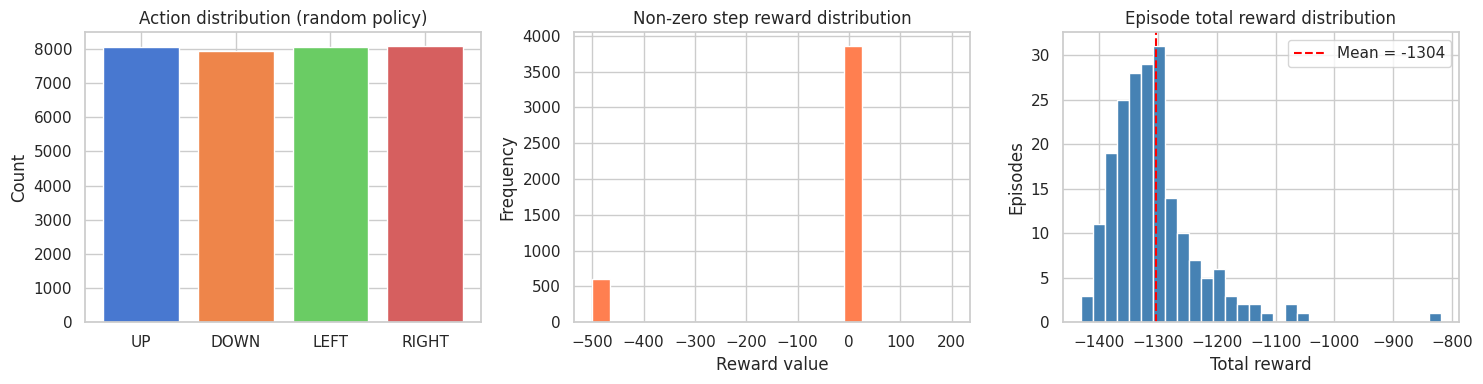

In [5]:
## 5. EDA — Action Space & Reward Distribution (random rollout)

N_EPISODES = 200
episode_rewards = []
episode_lengths = []
all_step_rewards = []
action_counts = Counter()

for ep in range(N_EPISODES):
    ep_env = PacmanEnv(seed=RANDOM_SEED + ep)
    ep_env.reset()
    done = False
    ep_reward = 0.0
    ep_len = 0
    while not done:
        action = ep_env.action_space.sample()
        action_counts[action] += 1
        _, reward, terminated, truncated, _ = ep_env.step(action)
        ep_reward += reward
        all_step_rewards.append(reward)
        ep_len += 1
        done = terminated or truncated
    episode_rewards.append(ep_reward)
    episode_lengths.append(ep_len)

print(f'Episodes: {N_EPISODES}  |  avg reward: {np.mean(episode_rewards):.1f}  |  avg length: {np.mean(episode_lengths):.1f} steps')

action_names = ['UP', 'DOWN', 'LEFT', 'RIGHT']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Action distribution
axes[0].bar(action_names, [action_counts[i] for i in range(4)], color=sns.color_palette('muted', 4))
axes[0].set_title('Action distribution (random policy)')
axes[0].set_ylabel('Count')

# Per-step reward distribution (non-zero only for clarity)
nonzero_rewards = [r for r in all_step_rewards if r != 0]
axes[1].hist(nonzero_rewards, bins=20, color='coral', edgecolor='white')
axes[1].set_title('Non-zero step reward distribution')
axes[1].set_xlabel('Reward value')
axes[1].set_ylabel('Frequency')

# Episode total reward distribution
axes[2].hist(episode_rewards, bins=30, color='steelblue', edgecolor='white')
axes[2].axvline(np.mean(episode_rewards), color='red', linestyle='--', label=f'Mean = {np.mean(episode_rewards):.0f}')
axes[2].set_title('Episode total reward distribution')
axes[2].set_xlabel('Total reward')
axes[2].set_ylabel('Episodes')
axes[2].legend()

plt.tight_layout()
plt.savefig('../reports/eda_rewards_actions.png', dpi=120)
plt.show()


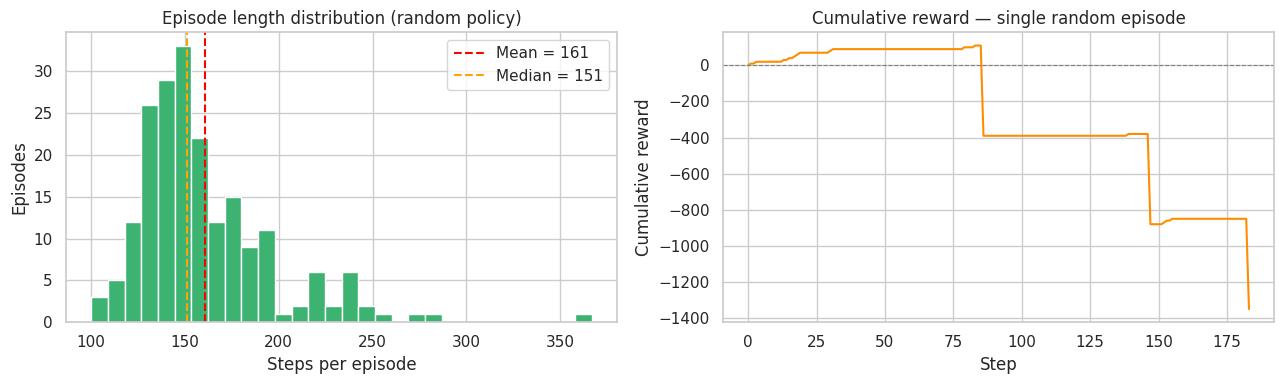

Episode length  min=100  max=367  mean=160.7  std=36.6


In [6]:
## 6. EDA — Episode Length Distribution

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(episode_lengths, bins=30, color='mediumseagreen', edgecolor='white')
axes[0].axvline(np.mean(episode_lengths), color='red', linestyle='--', label=f'Mean = {np.mean(episode_lengths):.0f}')
axes[0].axvline(np.median(episode_lengths), color='orange', linestyle='--', label=f'Median = {np.median(episode_lengths):.0f}')
axes[0].set_title('Episode length distribution (random policy)')
axes[0].set_xlabel('Steps per episode')
axes[0].set_ylabel('Episodes')
axes[0].legend()

# Cumulative reward over a single episode for illustration
single_env = PacmanEnv(seed=RANDOM_SEED)
single_env.reset()
done = False
cumulative = []
running = 0.0
while not done:
    _, reward, terminated, truncated, _ = single_env.step(single_env.action_space.sample())
    running += reward
    cumulative.append(running)
    done = terminated or truncated

axes[1].plot(cumulative, color='darkorange', linewidth=1.5)
axes[1].set_title('Cumulative reward — single random episode')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Cumulative reward')
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('../reports/eda_episode_lengths.png', dpi=120)
plt.show()

print(f'Episode length  min={min(episode_lengths)}  max={max(episode_lengths)}  mean={np.mean(episode_lengths):.1f}  std={np.std(episode_lengths):.1f}')


In [7]:
## 7. Summary

print('=== EDA Summary ===')
print(f'Observation vector length : {len(obs)}')
print(f'Action space size         : {env.action_space.n}  (UP / DOWN / LEFT / RIGHT)')
print(f'Board size                : {ROWS} × {COLS}')
print(f'  Walls                   : {int((maze == 1).sum())}')
print(f'  Pellets                 : {int((maze == 2).sum())}  (+{PELLET_SCORE} pts each)')
print(f'  Power pellets           : {int((maze == 3).sum())}  (+{POWER_PELLET_SCORE} pts each)')
print()
print(f'Random-policy baseline ({N_EPISODES} episodes):')
print(f'  Mean episode reward     : {np.mean(episode_rewards):.1f}  ± {np.std(episode_rewards):.1f}')
print(f'  Mean episode length     : {np.mean(episode_lengths):.1f}  ± {np.std(episode_lengths):.1f} steps')
print()
print('Saved EDA figures to reports/:')
print('  eda_observation_space.png')
print('  eda_maze_layout.png')
print('  eda_rewards_actions.png')
print('  eda_episode_lengths.png')


=== EDA Summary ===
Observation vector length : 891
Action space size         : 4  (UP / DOWN / LEFT / RIGHT)
Board size                : 31 × 28
  Walls                   : 548
  Pellets                 : 240  (+10 pts each)
  Power pellets           : 4  (+50 pts each)

Random-policy baseline (200 episodes):
  Mean episode reward     : -1303.5  ± 74.2
  Mean episode length     : 160.7  ± 36.6 steps

Saved EDA figures to reports/:
  eda_observation_space.png
  eda_maze_layout.png
  eda_rewards_actions.png
  eda_episode_lengths.png
